# Load pacakges and data

In [26]:
import xarray as xr
import numpy as np
import xskillscore as xs
import scipy as sp
import pandas as pd
from scipy.optimize import least_squares
import scipy.stats as stats
import statsmodels.api as sm

import matplotlib.pyplot as plt 
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import matplotlib.patches as patches 
from mpl_toolkits.axes_grid1 import host_subplot
from mpl_toolkits import axisartist
import matplotlib.gridspec as gridspec
import matplotlib.path as mpath
import cmocean

import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.util import add_cyclic_point
import cartopy.feature as cfeature

mpl.rcParams['font.family'] = 'sans-serif'
pic_dir = '../../output/figures/'

In [7]:
file_dir = '../../data/CESM2_clean_dataset/'
exps = ['LE', 
        'SF-GHG', 'SF-AAER',
        'SF-xAER','SF-BMB',
        'SF-EE', 'ssp585',  
        '1pctCO2','midHolocene',
        'lig127k','piControl'] 
colors = ['#ffcfd2',
          '#FF6600','#7B68EE',
          '#FFE600','#009900',
          '#A9A9A9','#f26a4f',
          '#ea84c9','#00FFFF',
          '#3399FF','#00FF80'] 

whi = {}
amoc = {}
for exp in exps: 
    print(exp)
    f = xr.open_mfdataset(file_dir+'AMOCI/CESM2*'+exp+'_AMOC40_ts*.nc',combine='by_coords')
    amoc[exp] = f[list(f.data_vars)[0]].load()
    f = xr.open_dataset(file_dir+'SSTand/CESM2-'+exp+'_WHI_full.nc')
    whi[exp] = f[list(f.data_vars)[0]]

LE
SF-GHG
SF-AAER
SF-xAER
SF-BMB
SF-EE
ssp585
1pctCO2
midHolocene
lig127k
piControl


In [8]:
# CPs and sensitivity values for fig.1b&c
params_cmip6_csv = pd.read_excel('../../data/diagnosis/CMIP6_4models_CPandSensitivityVlues.xlsx',header=None)
model_cmip6 = params_cmip6_csv.iloc[0].values
params_cmip6 = params_cmip6_csv.iloc[1:].values # sensitiivty 3, 2, 1, CP2, CP1

all_params = np.loadtxt("../../data/diagnosis/detection_subsampling_3runs_params_1000times.txt")
print(all_params.shape)
print(np.min(all_params,axis=0),'\n',(np.max(all_params,axis=0)))

(1000, 6)
[-12.6313  -0.2811   0.289    0.0865   9.94    17.51  ] 
 [-7.3989  0.222   0.5037  0.1173 14.66   20.6   ]


In [9]:
# Fingerprint for fig.1d
slope_regimes = {}
for regime in ['1','2','3']:
    slope_regimes['Regime'+regime] = -xr.open_dataset(file_dir+'Regime'+regime+'_all_AMOC&NASST_regression_slope.nc')['__xarray_dataarray_variable__']

In [10]:
# observed SST trend minus global mean trend as adopted from Fan et al. 2024
obs_sst_trd = xr.open_dataset('../../data/external/Fan24_dSSTminusGM_1900-2014_3DatasetAverage.nc')['sst_trend']

# Prepare data for plotting

In [12]:
def smooth(var,twindow=15):
    temp = var.rolling(year=twindow,center=True).mean('year')
    return temp.where(temp.isnull()==False,drop=True)

def dump_data(amoc, whi, exps=exps):
    amoc_dump = []
    whi_dump = []
    for e in exps:
        X = smooth(amoc[e]).values.flatten()
        Y = smooth(whi[e]).values.flatten()
        amoc_dump.extend(X.tolist())
        whi_dump.extend(Y.tolist())
    return np.array(amoc_dump), np.array(whi_dump)

# Plot

In [13]:
def smooth(var,twindow=15):
    temp = var.rolling(year=twindow,center=True).mean('year')
    return temp.where(temp.isnull()==False,drop=True)

def find_ols_params(x,y,cps):
    # find the ols parameters given the two change points 
    # cps: a list of change points
    xc1,xc2 = cps[:]
    x_temp = x[np.where((x>xc1)&(x<=xc2))[0]]
    y_temp = y[np.where((x>xc1)&(x<=xc2))[0]]
    mod=sm.OLS(y_temp,sm.add_constant(x_temp)).fit()
    b2 = mod.params[1] # slope of the second regime 
    y_xc1 = xc1*b2+mod.params[0] 
    y_xc2 = xc2*b2+mod.params[0] 
            
    x_temp1 = x[np.where(x<=xc1)[0]]-xc1
    y_temp1 = y[np.where(x<=xc1)[0]]-y_xc1
    def SSE(k,x=x_temp1,y=y_temp1):
        return np.sum((k*x-y)**2)
    b1 = least_squares(SSE,x0=np.array([0.2])).x[0]
    b0 = y_xc1-b1*xc1
            
    x_temp2 = x[np.where(x>xc2)[0]]-xc2
    y_temp2 = y[np.where(x>xc2)[0]]-y_xc2
    def SSE(k,x=x_temp2,y=y_temp2):
        return np.sum((k*x-y)**2)
    b3 = least_squares(SSE,x0=np.array([0.2])).x[0]
                        
    params = np.array([b0,b1,b2,b3,xc1,xc2])
    return params

def LinearFit(x,params):
    # linear fitting with two change points
    a,b1,b2,b3,xc1,xc2 = params
    y_pre = np.where(x<xc1,a+b1*x,a+b1*xc1+b2*(x-xc1))
    return np.where(x>=xc2,a+b1*xc1+b2*(xc2-xc1)+b3*(x-xc2),y_pre)

def conf_wbp(x, y, xin, cps, conf=0.95):
    # Calculates the confidence band of the linear regression model with break points
    # cps: list of break points 
    alpha=1.-conf # significance
    N=x.size # data sample size
    param = find_ols_params(x,y,cps)
    y_fit = LinearFit(x,param)
    y_pre = LinearFit(xin,param)
    s = np.sqrt(np.sum((y-y_fit)**2)/(N-2)) # the mean deviation of the data about the linear model
    # Standard errors of the estimated means from the sample x
    SE = s*np.sqrt(1./N + (xin-x.mean())**2/np.sum((x-x.mean())**2))
    # Quantile of Student's t distribution for p=1-alpha/2
    t=sp.stats.t.ppf(1.-alpha/2.,N-2)
    # Confidence band
    dy=t*SE
    uc = y_pre + dy	# Upper confidence band
    lc = y_pre - dy	# Lower confidence band
    return xin, lc, uc, y_pre, param

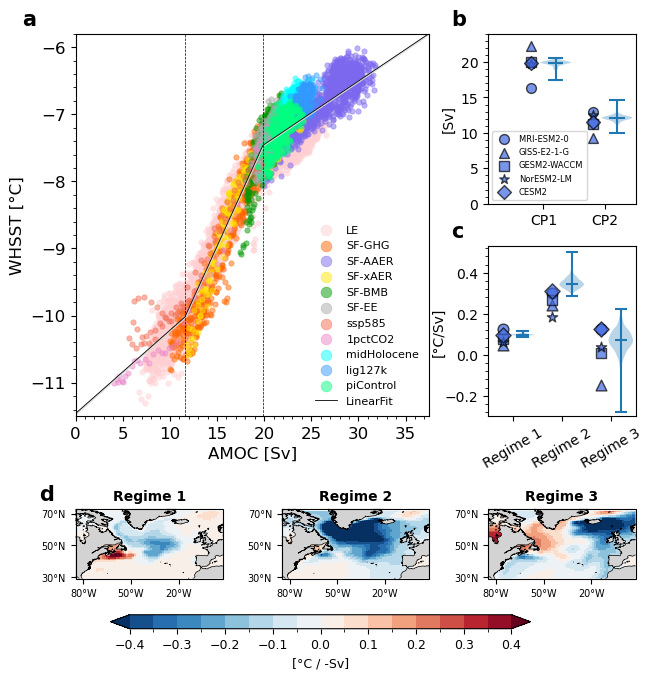

In [46]:
fig = plt.figure(figsize=(7, 7))
plt.subplots_adjust(top=0.95, bottom=0.1,left=0.15,right=0.95,hspace=0.25,wspace=0.4)
ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=2,rowspan=2)
ax2 = plt.subplot2grid((3, 3), (0, 2))
ax3 = plt.subplot2grid((3, 3), (1, 2))
ax4 = plt.subplot2grid((3, 3), (2, 0), projection=ccrs.PlateCarree())
ax5 = plt.subplot2grid((3, 3), (2, 1), projection=ccrs.PlateCarree())
ax6 = plt.subplot2grid((3, 3), (2, 2), projection=ccrs.PlateCarree())

interval = 3
## (a)
amoc_dump = []
whi_dump = []

for i in range(len(exps)):
    X = smooth(amoc[exps[i]]).values.flatten()
    Y = smooth(whi[exps[i]]).values.flatten()
    ax1.scatter(X[::interval],Y[::interval],c=colors[i],alpha=0.5,s=15,marker='o',label=exps[i],edgecolor=colors[i],linewidths=0.5,zorder=2)
    amoc_dump.extend(X.tolist())
    whi_dump.extend(Y.tolist())

xc1,xc2 = params_cmip6[-2:,-1]
x = np.array(amoc_dump)
y = np.array(whi_dump)
xin=np.arange(0,38+0.1,0.1)
xin,lc,uc,y_pre, param = conf_wbp(x,y,xin,cps=[xc1,xc2])
ax1.fill_between(xin,lc,uc, alpha=0.8, color='gainsboro',zorder=2)
ax1.plot(xin,y_pre,lw=0.6,c='k',label='LinearFit',zorder=2)
ax1.set_ylabel('WHSST [\u00B0C]',fontsize=12)
ax1.set_xlabel('AMOC [Sv]',fontsize=12)
ax1.legend(loc='lower right',ncol=1,fontsize=8,markerscale=2,frameon=False)
ax1.set_ylim(-11.5,-5.8)
ax1.set_xlim(0,37.5)
ax1.axvline(x=xc1,c='k',ls='dashed',lw=0.5,zorder=2)
ax1.axvline(x=xc2,c='k',ls='dashed',lw=0.5,zorder=2)

y_minor_locator=MultipleLocator(0.2)
y_major_locator=MultipleLocator(1)
x_minor_locator=MultipleLocator(1)
x_major_locator=MultipleLocator(5)
ax1.yaxis.set_major_locator(y_major_locator)
ax1.yaxis.set_minor_locator(y_minor_locator)
ax1.xaxis.set_major_locator(x_major_locator)
ax1.xaxis.set_minor_locator(x_minor_locator)
ax1.tick_params(labelsize=12)
ax1.set_title('a',loc='left',fontdict={'weight': 'bold', 'size': 15},x=-0.15)

## (b) & (c)
scatters = ['o','^','s','*','D']
for i in range(5):
    ax2.scatter(1-0.2,params_cmip6[-2,i],marker=scatters[i],label=model_cmip6[i],c='royalblue',edgecolor='k',alpha=0.7,s=50)
    ax2.scatter(0-0.2,params_cmip6[-1,i],marker=scatters[i],c='royalblue',edgecolor='k',alpha=0.7,s=50)
    #ax3.plot(np.arange(0,3), params_cmip6[:3,i][::-1],lw=1,c='silver',zorder=2)
    ax3.scatter(np.arange(0,3)-0.2,params_cmip6[:3,i][::-1],marker=scatters[i],c='royalblue',edgecolor='k',alpha=0.7,s=60,zorder=2)

# add uncertainty range estimated from subsampling CESM2 
ax2.violinplot(all_params[:,-2:], positions=[1.2,0.2],showmedians=True)

ax2.set_xticks(np.array([0,1]),['CP1','CP2'])
ax2.set_xlim(-0.9,1.5)
ax2.set_ylabel('[Sv]',fontsize=10)
ax2.set_ylim(0,24)
ax2.legend(loc='lower left',fontsize=6)
ax2.set_title('b',loc='left',fontdict={'weight': 'bold', 'size': 15},x=-0.25)
y_minor_locator=MultipleLocator(1)
y_major_locator=MultipleLocator(5)
ax2.yaxis.set_major_locator(y_major_locator)
ax2.yaxis.set_minor_locator(y_minor_locator)

ax3.violinplot(all_params[:,1:4], positions=[2.2,1.2,0.2],showmedians=True)
ax3.set_xticks(np.array([0,1,2]),['Regime 1','Regime 2','Regime 3'],rotation=30)
ax3.set_xlim(-0.5,2.5)
#ax3.set_ylim(-0.22,0.38)
ax3.set_ylim(-0.3,0.53)
ax3.set_ylabel('[\u00B0C/Sv]',fontsize=10, labelpad=-1)
ax3.set_title('c',loc='left',fontdict={'weight': 'bold', 'size': 15},x=-0.25)
y_minor_locator=MultipleLocator(0.04)
y_major_locator=MultipleLocator(0.2)
ax3.yaxis.set_major_locator(y_major_locator)
ax3.yaxis.set_minor_locator(y_minor_locator)

for ax in [ax2,ax3]:
    ax.tick_params(labelsize=10)

# (d)
xticks = np.arange(-170, 180, 30)
yticks = np.arange(-90, 90.1, 20)

i=0
for ax in [ax4,ax5,ax6]:
    cs = slope_regimes['Regime'+str(i+1)].plot(ax=ax,levels=np.arange(-0.4,0.45,0.05),transform=ccrs.PlateCarree(),
                                               extend='both',add_colorbar=False,add_labels=False)
    ax.set_title('Regime '+str(i+1),loc='center',fontdict={'weight': 'bold', 'size': 10})
    ax.add_feature(cfeature.LAND,zorder=1,fc='lightgrey')
    ax.add_feature(cfeature.COASTLINE,zorder=1.2, lw=0.5)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(axis='both', labelsize=7)
    ax.set_extent([-85, 8, 29, 66])
    i=i+1
    
cax = plt.axes([0.2, 0.1, 0.6, 0.02])  
cb = plt.colorbar(cs, cax=cax, drawedges=0,orientation='horizontal')
cb.set_label('[\u00B0C / -Sv]',fontsize=9)
cb.ax.tick_params(labelsize=9)
ax4.set_title('d',loc='left',fontdict={'weight': 'bold', 'size': 15},x=-0.25)
#plt.tight_layout()
plt.savefig(pic_dir+'F1_alternative.pdf')
plt.show()

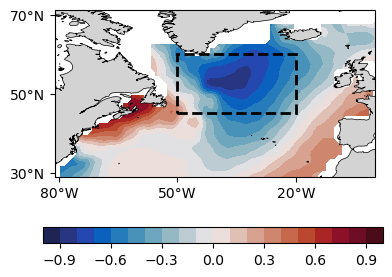

In [58]:
# inserted map
fig,ax = plt.subplots(1,1,subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=310)),
                       sharex=True, sharey=True, figsize=(4,4)) 
plt.subplots_adjust(top=0.95,bottom=0.2,left=0.15,right=0.95,wspace=0.1,hspace=0.1)
clevs = np.arange(-1,1.1, 0.1)
cycle_term,cycle_lon  = add_cyclic_point(obs_sst_trd,coord=obs_sst_trd.lon.values)
cycle_lons, cycle_lats = np.meshgrid(cycle_lon,obs_sst_trd.lat.values)
cs = ax.contourf(cycle_lons, cycle_lats, cycle_term, clevs,cmap=cmocean.cm.balance, extend='neither',transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND,zorder=1,fc='lightgrey')
ax.add_feature(cfeature.COASTLINE,zorder=1.2, lw=0.5)
ax.add_patch(patches.Rectangle((310, 45),30,15,edgecolor = 'black',linestyle='--',linewidth=2,fill=False,transform=ccrs.PlateCarree()))
ax.set_xticks(xticks, crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
ax.set_yticks(yticks, crs=ccrs.PlateCarree())
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.set_extent([-81, 0, 29, 66])
cax = plt.axes([0.12, 0.2, 0.85,0.04]) 
cb = plt.colorbar(cs, cax=cax, drawedges=0,orientation='horizontal')
plt.savefig(pic_dir+'F1_map_obsWHSSTtrend.pdf',dpi=1200)
plt.show()